# LAB06

## **Esercizio 6.1**

#### INTRODUZIONE
In questo esercizio viene studiato il modello di Ising monodimensionale: gli spin di un sistema non sono indipendenti ma interagiscono con i vicini più prossimi; si assume che l'interazione sia $J=1$, quindi il sistema favorisce l'allineamento degli spin, e che siano presenti $N=50$ spin. Il sistema è descritto dall’Hamiltoniana del modello di Ising e viene campionato secondo la distribuzione di Boltzmann $p({s_i})= \frac{e^{-\beta H}}{Z}$.

Per generare le configurazioni di spin si utilizzano due algoritmi Monte Carlo: il metodo di Metropolis e il campionamento di Gibbs. Ogni step della simulazione consiste nel tentativo di aggiornamento di tutti gli spin del sistema. Nel caso del metodo di Metropolis, ogni spin viene aggiornato accettando o rifiutando il flip secondo la probabilità di Boltzmann. Invece, nel caso del campionamento di Gibbs, ogni spin viene aggiornato direttamente secondo la distribuzione condizionata (si elimina quindi il meccanismo di accettazione/rifiuto). L’obiettivo è confrontare i due metodi e studiare l’andamento delle principali grandezze termodinamiche al variare della temperatura nell’intervallo $T \in [0.5, 2.0]$. 

Le osservabili calcolate sono: 
- energia interna $U = \braket{H}$
- capacità termica $ C = \beta^2 (\braket{H^2} - \braket{H}^2)$
- suscettività magnetica $\chi = \beta \braket{(\sum_i s_i)^2}$
- magnetizzazione $M = \braket{\sum_{i=1}s_i}$ in presenza di campo magnetico esterno $h=0.02$.


#### IMPLEMENTAZIONE C++
Innanzitutto, è stata modificata la funzione `System :: move(int i)` al fine di implementare il campionamento di Gibbs. Per ogni spin $i$, si calcola il campo efficace dovuto ai suoi vicini e all’eventuale campo esterno come: 
$$ h_{eff} = J \cdot (s_{i-1} + s_{i+1}) + H $$
Dunque, sfruttando distribuzione di Boltzmann applicata all’energia locale dello spin, la probabilità che lo spin assuma valore +1 è: 
$$ p(s_i = +1) = \frac{1}{1+e^{-2 \beta h_{eff}}} $$

Una volta calcolata la probabilità $p$, si genera un numero casuale uniforme $r \in [0,1]$. Lo spin viene aggiornato come:
- $s_i = 1$ se $r<p$
- $s_i = -1$ altrimenti

In questo modo lo spin viene campionato esattamente dalla sua distribuzione condizionata.

Poi è stata modificata la funzione `System :: measure`, in modo da misurare le quantità desiderate. In particolare, la magnetizzazione totale del sistema viene calcolata come somma di tutti gli spin; viene poi normalizzata per ottenere la magnetizzazione per spin. Per quanto riguarda il calore specifico, il codice accumula solamente $\braket{E^2}$, poichè l'energia media è stata già calcolata: queste due quantità verranno combinate successivamente. Invece, per la suscettività magnetica viene salvato il quadrato della magnetizzazione, mentre il parametro $\beta$ è introdotto in seguito. 

Infine, è stata modificata la fuzione `System :: averages`, in modo che tutte le quantità siano stimate utilizzando il metodo del data blocking; in particolare, si utilizzano 20 blocchi da 20000 passi ciascuno. Per ogni temperatura, prima della raccolta dei dati, si esegue una fase di equilibrazione per garantire che il sistema abbia raggiunto appunto uno stato di equilibrio. 


#### ANALISI DEI RISULTATI
Nei seguenti grafici sono riportati i risultati delle simulazioni eseguite con il metodo di Metropolis e di Gibbs al variare della temperatura, entrambi confrontati con il valore teorico. Inoltre, per ogni grandezza è riportato un ulteriore grafico che mostra gli scarti delle due simulazioni dal valore teorico, con le rispettive barre di errore. 

In generale, i risultati ottenuti con entrambi i metodi simulativi risultano in buon accordo con i valori teorici: la maggior parte dei punti è compatibile entro $\sigma$, mentre solo pochi casi isolati mostrano scarti leggermente maggiori, comunque contenuti entro $2\sigma$ o $3\sigma$. 

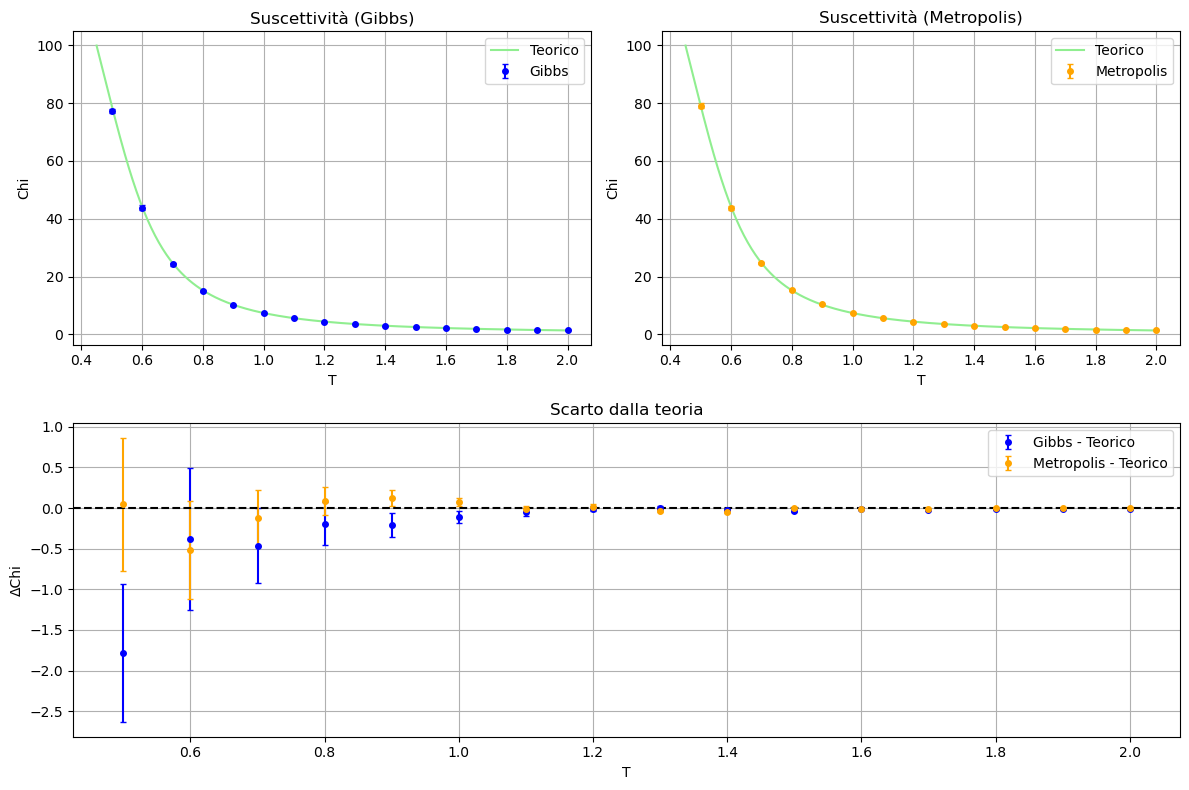

In [20]:
# SUSCETTIVITA'

import numpy as np
import matplotlib.pyplot as plt

# LETTURA DATI DA FILE
chi_gibbs = np.loadtxt("NSL_SIMULATOR/OUTPUT/PLOT/chi_gibbs.dat")
chi_metro = np.loadtxt("NSL_SIMULATOR/OUTPUT/PLOT/chi_metro.dat")

t_gibbs = chi_gibbs[:,0]
t_metro = chi_metro[:,0]
av_gibbs = chi_gibbs[:,2]
av_metro = chi_metro[:,2]
err_gibbs = chi_gibbs[:,3]
err_metro = chi_metro[:,3]

T_th = np.linspace(0.45, max(t_gibbs), 500)

# =========================
# TEORICO
# =========================
J = 1.0
Ns = 50
th = np.tanh(J/T_th)
thN = th**Ns
ch = 1/th
beta = 1/(T_th)

X = beta * np.exp(2*beta*J) * (1 - thN) / (1 + thN)

# =========================
# SCARTI (interpolazione)
# =========================
X_gibbs = np.interp(t_gibbs, T_th, X)
X_metro = np.interp(t_metro, T_th, X)

scarto_gibbs = av_gibbs - X_gibbs
scarto_metro = av_metro - X_metro

# =========================
# PLOT
# =========================
fig = plt.figure(figsize=(12,8))
gs = fig.add_gridspec(2, 2)

# --- Gibbs ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(t_gibbs, av_gibbs, yerr=err_gibbs,
             fmt='o', markersize=4,
             color='blue', label="Gibbs", capsize=2)

ax1.plot(T_th, X, color='lightgreen', label="Teorico")

ax1.set_xlabel("T")
ax1.set_ylabel("Chi")
ax1.set_title("Suscettività (Gibbs)")
ax1.legend()
ax1.grid(True)

# --- Metropolis ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.errorbar(t_metro, av_metro, yerr=err_metro,
             fmt='o', markersize=4,
             color='orange', label="Metropolis", capsize=2)

ax2.plot(T_th, X, color='lightgreen', label="Teorico")

ax2.set_xlabel("T")
ax2.set_ylabel("Chi")
ax2.set_title("Suscettività (Metropolis)")
ax2.legend()
ax2.grid(True)

# --- Scarti ---
ax3 = fig.add_subplot(gs[1, :])

ax3.errorbar(t_gibbs, scarto_gibbs, yerr=err_gibbs,
             fmt='o', markersize=4,
             color='blue', label="Gibbs - Teorico", capsize=2)

ax3.errorbar(t_metro, scarto_metro, yerr=err_metro,
             fmt='o', markersize=4,
             color='orange', label="Metropolis - Teorico", capsize=2)

ax3.axhline(0, color='black', linestyle='--')

ax3.set_xlabel("T")
ax3.set_ylabel("ΔChi")
ax3.set_title("Scarto dalla teoria")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

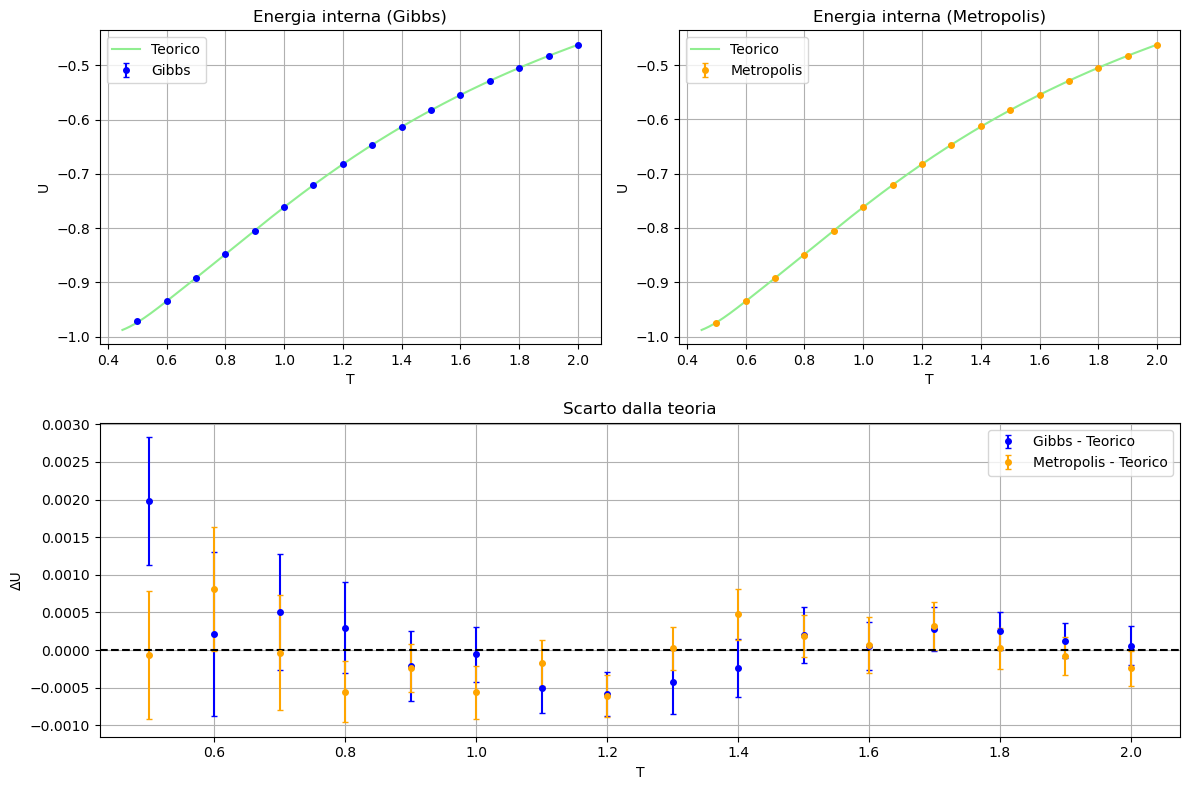

In [22]:
# ENERGIA INTERNA 

import numpy as np
import matplotlib.pyplot as plt

# LETTURA DATI DA FILE
tenergy_gibbs = np.loadtxt("NSL_SIMULATOR/OUTPUT/PLOT/tenergy_gibbs.dat")
tenergy_metro = np.loadtxt("NSL_SIMULATOR/OUTPUT/PLOT/tenergy_metro.dat")

t_gibbs = tenergy_gibbs[:,0]
t_metro = tenergy_metro[:,0]
av_gibbs = tenergy_gibbs[:,2]
av_metro = tenergy_metro[:,2]
err_gibbs = tenergy_gibbs[:,3]
err_metro = tenergy_metro[:,3]

T_th = np.linspace(0.45, max(t_gibbs), 500)

# =========================
# TEORICO
# =========================
J = 1.0
Ns = 50
th = np.tanh(J/T_th)
thN = th**Ns
ch = 1/th

e = -J*(th + ch*thN)/(1 + thN)

# =========================
# SCARTI (interpolazione)
# =========================
e_gibbs = np.interp(t_gibbs, T_th, e)
e_metro = np.interp(t_metro, T_th, e)

scarto_gibbs = av_gibbs - e_gibbs
scarto_metro = av_metro - e_metro

# =========================
# PLOT
# =========================
fig = plt.figure(figsize=(12,8))
gs = fig.add_gridspec(2, 2)

# --- Gibbs ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(t_gibbs, av_gibbs, yerr=err_gibbs,
             fmt='o', markersize=4,
             color='blue', label="Gibbs", capsize=2)

ax1.plot(T_th, e, color='lightgreen', label="Teorico")

ax1.set_xlabel("T")
ax1.set_ylabel("U")
ax1.set_title("Energia interna (Gibbs)")
ax1.legend()
ax1.grid(True)

# --- Metropolis ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.errorbar(t_metro, av_metro, yerr=err_metro,
             fmt='o', markersize=4,
             color='orange', label="Metropolis", capsize=2)

ax2.plot(T_th, e, color='lightgreen', label="Teorico")

ax2.set_xlabel("T")
ax2.set_ylabel("U")
ax2.set_title("Energia interna (Metropolis)")
ax2.legend()
ax2.grid(True)

# --- Scarti ---
ax3 = fig.add_subplot(gs[1, :])

ax3.errorbar(t_gibbs, scarto_gibbs, yerr=err_gibbs,
             fmt='o', markersize=4,
             color='blue', label="Gibbs - Teorico", capsize=2)

ax3.errorbar(t_metro, scarto_metro, yerr=err_metro,
             fmt='o', markersize=4,
             color='orange', label="Metropolis - Teorico", capsize=2)

ax3.axhline(0, color='black', linestyle='--')

ax3.set_xlabel("T")
ax3.set_ylabel("ΔU")
ax3.set_title("Scarto dalla teoria")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()


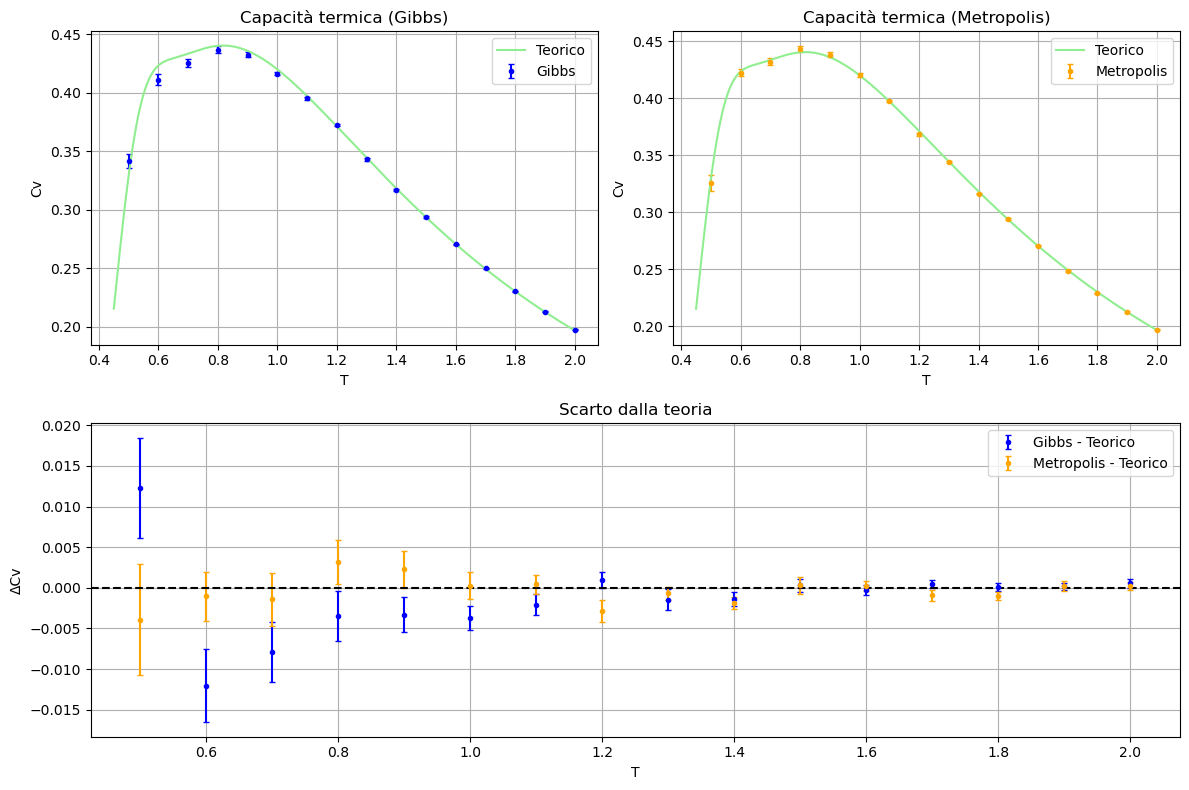

In [17]:
# CAPACITA' TERMICA
import numpy as np
import matplotlib.pyplot as plt

# LETTURA DATI DA FILE
cv_gibbs = np.loadtxt("NSL_SIMULATOR/OUTPUT/PLOT/cv_gibbs.dat")
cv_metro = np.loadtxt("NSL_SIMULATOR/OUTPUT/PLOT/cv_metro.dat")

t_gibbs = cv_gibbs[:,0]
t_metro = cv_metro[:,0]
av_gibbs = cv_gibbs[:,2]
av_metro = cv_metro[:,2]
err_gibbs = cv_gibbs[:,3]
err_metro = cv_metro[:,3]

T_th = np.linspace(0.45, max(t_gibbs), 500)

# TEORICO
J = 1.0
Ns = 50
th = np.tanh(J/T_th)
thN = th**Ns
ch = 1/th
beta = 1/(T_th)

heat = ((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))
        - Ns*((th+ch*thN)/(1+thN))**2)

# =========================
# SCARTI (interpolazione)
# =========================
heat_gibbs = np.interp(t_gibbs, T_th, heat)
heat_metro = np.interp(t_metro, T_th, heat)

scarto_gibbs = av_gibbs - heat_gibbs
scarto_metro = av_metro - heat_metro

# =========================
# PLOT
# =========================
fig = plt.figure(figsize=(12,8))
gs = fig.add_gridspec(2, 2)

# --- Gibbs ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(t_gibbs, av_gibbs, yerr=err_gibbs,
             fmt='o', markersize=3,
             color='blue', label="Gibbs", capsize=2)

ax1.plot(T_th, heat, color='lightgreen', label="Teorico")

ax1.set_xlabel("T")
ax1.set_ylabel("Cv")
ax1.set_title("Capacità termica (Gibbs)")
ax1.legend()
ax1.grid(True)

# --- Metropolis ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.errorbar(t_metro, av_metro, yerr=err_metro,
             fmt='o', markersize=3,
             color='orange', label="Metropolis", capsize=2)

ax2.plot(T_th, heat, color='lightgreen', label="Teorico")

ax2.set_xlabel("T")
ax2.set_ylabel("Cv")
ax2.set_title("Capacità termica (Metropolis)")
ax2.legend()
ax2.grid(True)

# --- Scarti ---
ax3 = fig.add_subplot(gs[1, :])

ax3.errorbar(t_gibbs, scarto_gibbs, yerr=err_gibbs,
             fmt='o', markersize=3,
             color='blue', label="Gibbs - Teorico", capsize=2)

ax3.errorbar(t_metro, scarto_metro, yerr=err_metro,
             fmt='o', markersize=3,
             color='orange', label="Metropolis - Teorico", capsize=2)

ax3.axhline(0, color='black', linestyle='--')

ax3.set_xlabel("T")
ax3.set_ylabel("ΔCv")
ax3.set_title("Scarto dalla teoria")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()



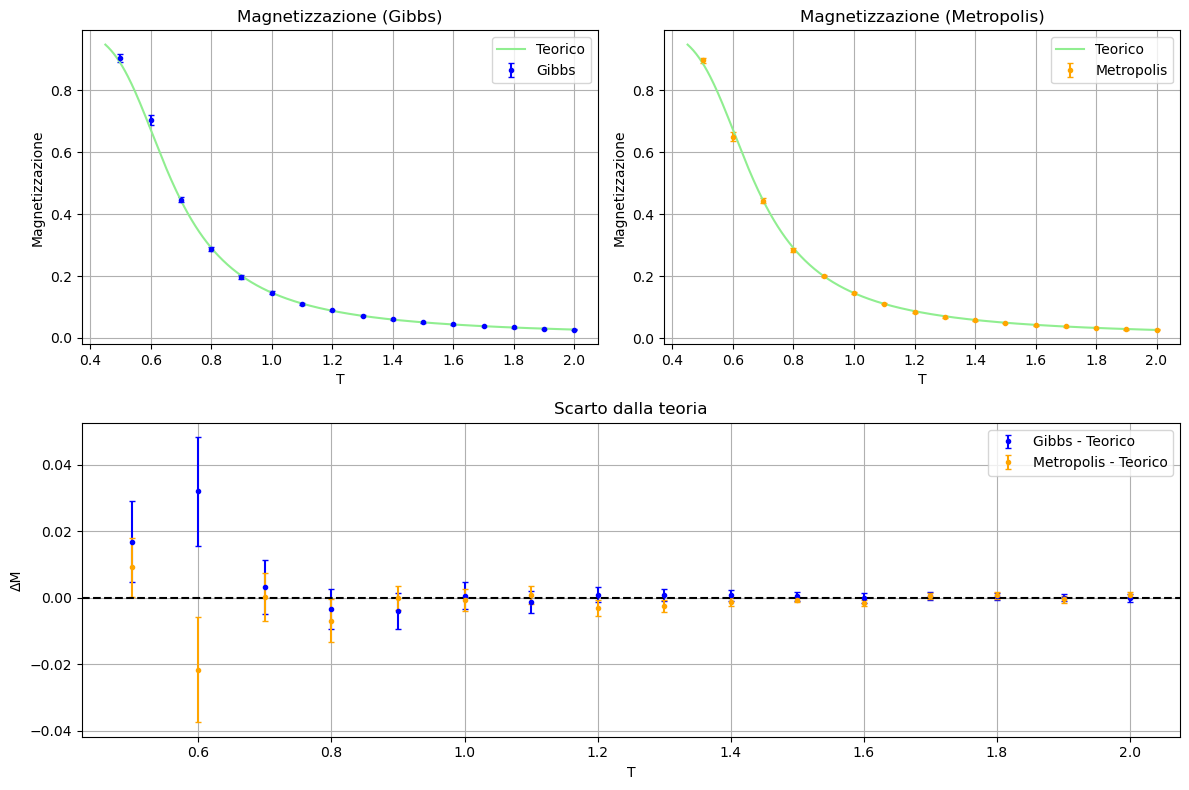

In [23]:
# MAGNETIZZAZIONE

import numpy as np
import matplotlib.pyplot as plt

# LETTURA DATI DA FILE
magnet_gibbs = np.loadtxt("NSL_SIMULATOR/OUTPUT/PLOT/magnet_gibbs.dat")
magnet_metro = np.loadtxt("NSL_SIMULATOR/OUTPUT/PLOT/magnet_metro.dat")

t_gibbs = magnet_gibbs[:,0]
t_metro = magnet_metro[:,0]
av_gibbs = magnet_gibbs[:,2]
av_metro = magnet_metro[:,2]
err_gibbs = magnet_gibbs[:,3]
err_metro = magnet_metro[:,3]

T_th = np.linspace(0.45, max(t_gibbs), 500)

# =========================
# TEORICO
# =========================
J = 1.0
Ns = 50
h = 0.02

th = np.tanh(J/T_th)
thN = th**Ns
ch = 1/th
b = 1/(T_th)

l1 = np.exp(b*J)*np.cosh(b*h) + np.sqrt(np.exp(2*b*J)*np.cosh(b*h)**2 - 2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h) - np.sqrt(np.exp(2*b*J)*np.cosh(b*h)**2 - 2*np.sinh(2*b*J))

Z = l1**Ns + l2**Ns

M = (np.exp(b*J)*np.sinh(b*h)*(
     (l1**(Ns-1))*(1 + np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)**2 - 2*np.sinh(2*b*J))) +
     (l2**(Ns-1))*(1 - np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)**2 - 2*np.sinh(2*b*J)))
     )) / Z

# =========================
# SCARTI (interpolazione)
# =========================
M_gibbs = np.interp(t_gibbs, T_th, M)
M_metro = np.interp(t_metro, T_th, M)

scarto_gibbs = av_gibbs - M_gibbs
scarto_metro = av_metro - M_metro

# =========================
# PLOT
# =========================
fig = plt.figure(figsize=(12,8))
gs = fig.add_gridspec(2, 2)

# --- Gibbs ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(t_gibbs, av_gibbs, yerr=err_gibbs,
             fmt='o', markersize=3,
             color='blue', label="Gibbs", capsize=2)

ax1.plot(T_th, M, color='lightgreen', label="Teorico")

ax1.set_xlabel("T")
ax1.set_ylabel("Magnetizzazione")
ax1.set_title("Magnetizzazione (Gibbs)")
ax1.legend()
ax1.grid(True)

# --- Metropolis ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.errorbar(t_metro, av_metro, yerr=err_metro,
             fmt='o', markersize=3,
             color='orange', label="Metropolis", capsize=2)

ax2.plot(T_th, M, color='lightgreen', label="Teorico")

ax2.set_xlabel("T")
ax2.set_ylabel("Magnetizzazione")
ax2.set_title("Magnetizzazione (Metropolis)")
ax2.legend()
ax2.grid(True)

# --- Scarti ---
ax3 = fig.add_subplot(gs[1, :])

ax3.errorbar(t_gibbs, scarto_gibbs, yerr=err_gibbs,
             fmt='o', markersize=3,
             color='blue', label="Gibbs - Teorico", capsize=2)

ax3.errorbar(t_metro, scarto_metro, yerr=err_metro,
             fmt='o', markersize=3,
             color='orange', label="Metropolis - Teorico", capsize=2)

ax3.axhline(0, color='black', linestyle='--')

ax3.set_xlabel("T")
ax3.set_ylabel("ΔM")
ax3.set_title("Scarto dalla teoria")
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()